# ESM_PDB1 Training Monitor

Live monitoring notebook for the `esm2_650M_triplet_v1` training run.
Re-run cells to refresh with the latest data.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import polars as pl

plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["figure.dpi"] = 100

METRICS_PATH = Path("../outputs/esm2_650M_triplet_v1/eval_metrics.csv")

def load_metrics(path=METRICS_PATH):
    df = pl.read_csv(path)
    return {
        "all": df,
        "train": df.filter(pl.col("DATASET") == "TRAIN"),
        "test": df.filter(pl.col("DATASET") == "TEST"),
        "val": df.filter(pl.col("DATASET") == "VAL"),
    }

m = load_metrics()
print(f"Loaded {len(m['all'])} rows — {m['train']['EPOCH'].max()} epochs completed")
print(f"Splits: TRAIN={len(m['train'])}, TEST={len(m['test'])}, VAL={len(m['val'])}")
m["train"].tail(3)

Loaded 75 rows — 24 epochs completed
Splits: TRAIN=25, TEST=25, VAL=25


EPOCH,DATASET,UNBALANCED_LOSS,NEGATIVE_PAIR_LOSS,SAME_AG_LOSS,OVERLAPPING_EPITOPE_LOSS,BALANCED_LOSS,UNBALANCED_LOSS_VS_TEST,NEGATIVE_PAIR_LOSS_VS_TEST,SAME_AG_LOSS_VS_TEST,OVERLAPPING_EPITOPE_LOSS_VS_TEST,BALANCED_LOSS_VS_TEST,NORM_BINARY_ACC_EP,NORM_COS_SIM_THRESH_EP,TOT_BINARY_ACC_EP,TOT_COS_SIM_THRESH_EP,NORM_BINARY_ACC_AG,NORM_COS_SIM_THRESH_AG,TOT_BINARY_ACC_AG,TOT_COS_SIM_THRESH_AG,NEAREST_NEIGHBOR_ACC_AG,NEAREST_NEIGHBOR_ACC_EP,ACTUAL_BEST_PRED_RANK,PRED_BEST_ACT_RANK,F1_AG
i64,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
22,"""TRAIN""",3.760009,4.11278,0.281284,0.380026,1.591363,3.760009,4.11278,0.281284,0.380026,1.591363,0.844239,0.668342,0.96646,1.0,0.858582,0.628141,0.907687,1.0,0.454186,0.340145,197.764954,582.737122,0.394309
23,"""TRAIN""",3.777323,4.127427,0.283029,0.49643,1.635629,3.777323,4.127427,0.283029,0.49643,1.635629,0.805585,0.577889,0.966469,1.0,0.830321,0.59799,0.907695,1.0,0.456823,0.35267,222.907455,581.699402,0.395914
24,"""TRAIN""",3.824114,4.181117,0.264536,0.472267,1.639307,3.824114,4.181117,0.264536,0.472267,1.639307,0.800614,0.58794,0.966472,1.0,0.822829,0.59799,0.907699,1.0,0.456823,0.343441,197.280914,569.248169,0.398603


## Loss Curves

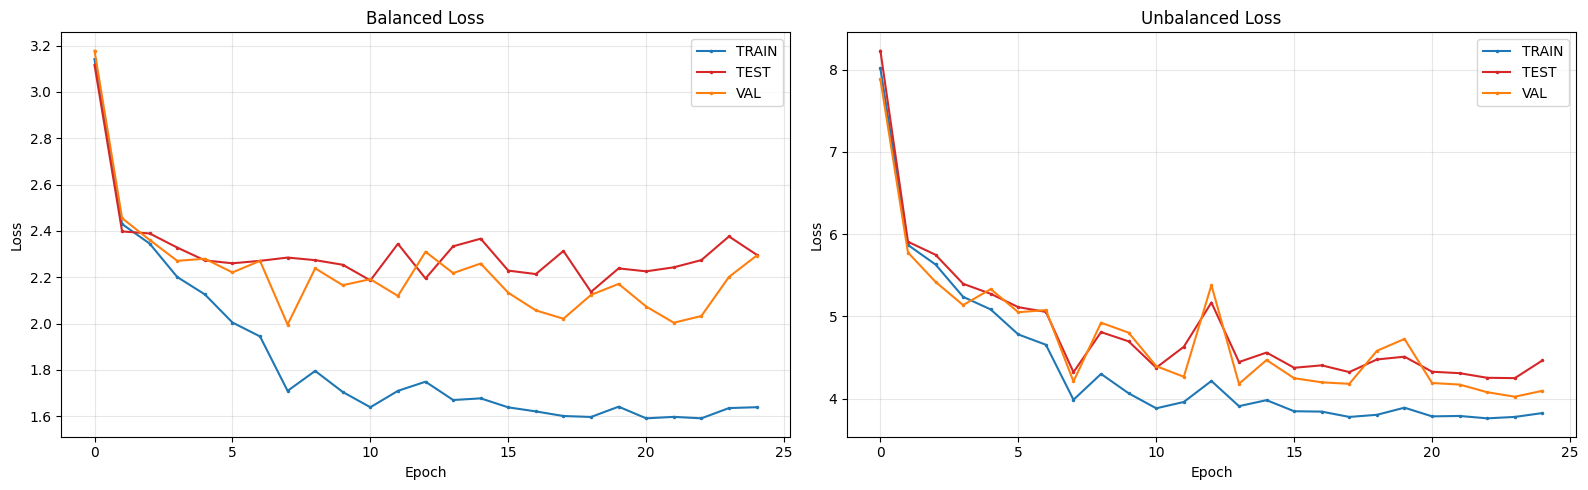

In [3]:
SPLITS = {"train": "tab:blue", "test": "tab:red", "val": "tab:orange"}

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for col, ax, title in [
    ("BALANCED_LOSS", axes[0], "Balanced Loss"),
    ("UNBALANCED_LOSS", axes[1], "Unbalanced Loss"),
]:
    for split, colour in SPLITS.items():
        ax.plot(m[split]["EPOCH"], m[split][col], label=split.upper(), color=colour, marker=".", ms=3)
    ax.set(xlabel="Epoch", ylabel="Loss", title=title)
    ax.legend()
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Component Losses (Negative, Same-AG, Overlapping-EP)

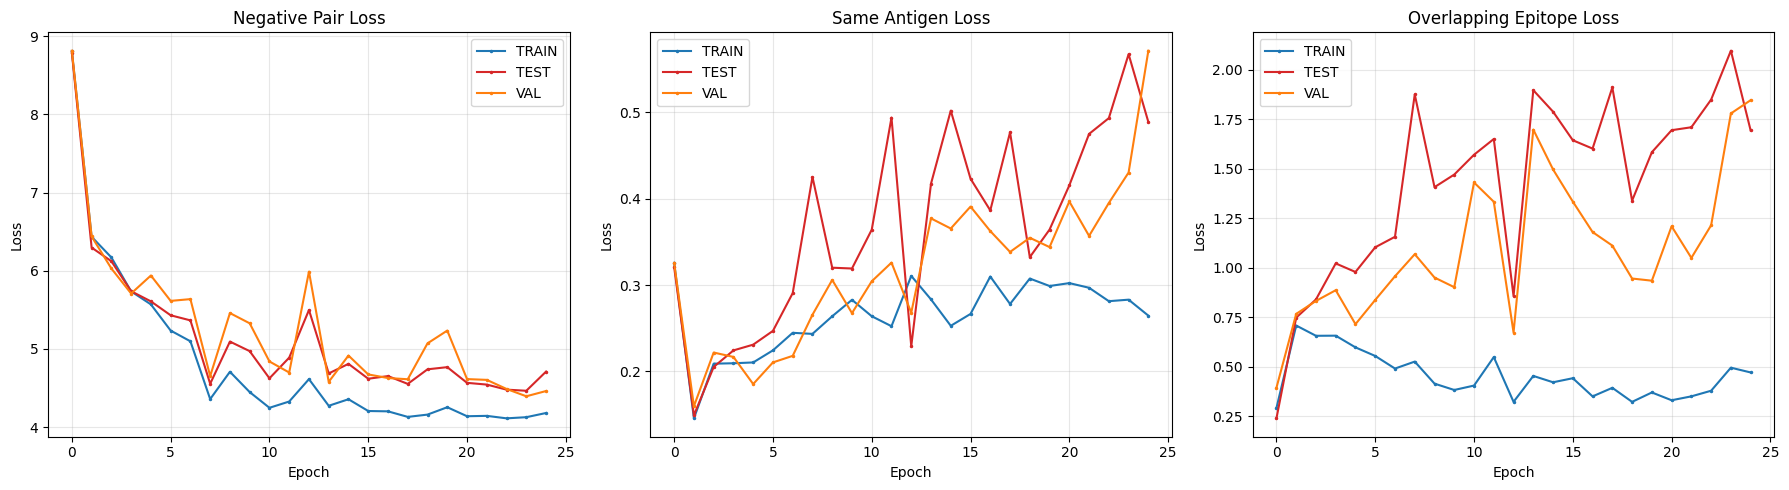

In [4]:
components = [
    ("NEGATIVE_PAIR_LOSS", "Negative Pair Loss"),
    ("SAME_AG_LOSS", "Same Antigen Loss"),
    ("OVERLAPPING_EPITOPE_LOSS", "Overlapping Epitope Loss"),
]
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for (col, title), ax in zip(components, axes):
    for split, colour in SPLITS.items():
        ax.plot(m[split]["EPOCH"], m[split][col], label=split.upper(), color=colour, marker=".", ms=3)
    ax.set(xlabel="Epoch", ylabel="Loss", title=title)
    ax.legend()
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Generalisation Gap (Test/Val minus Train)

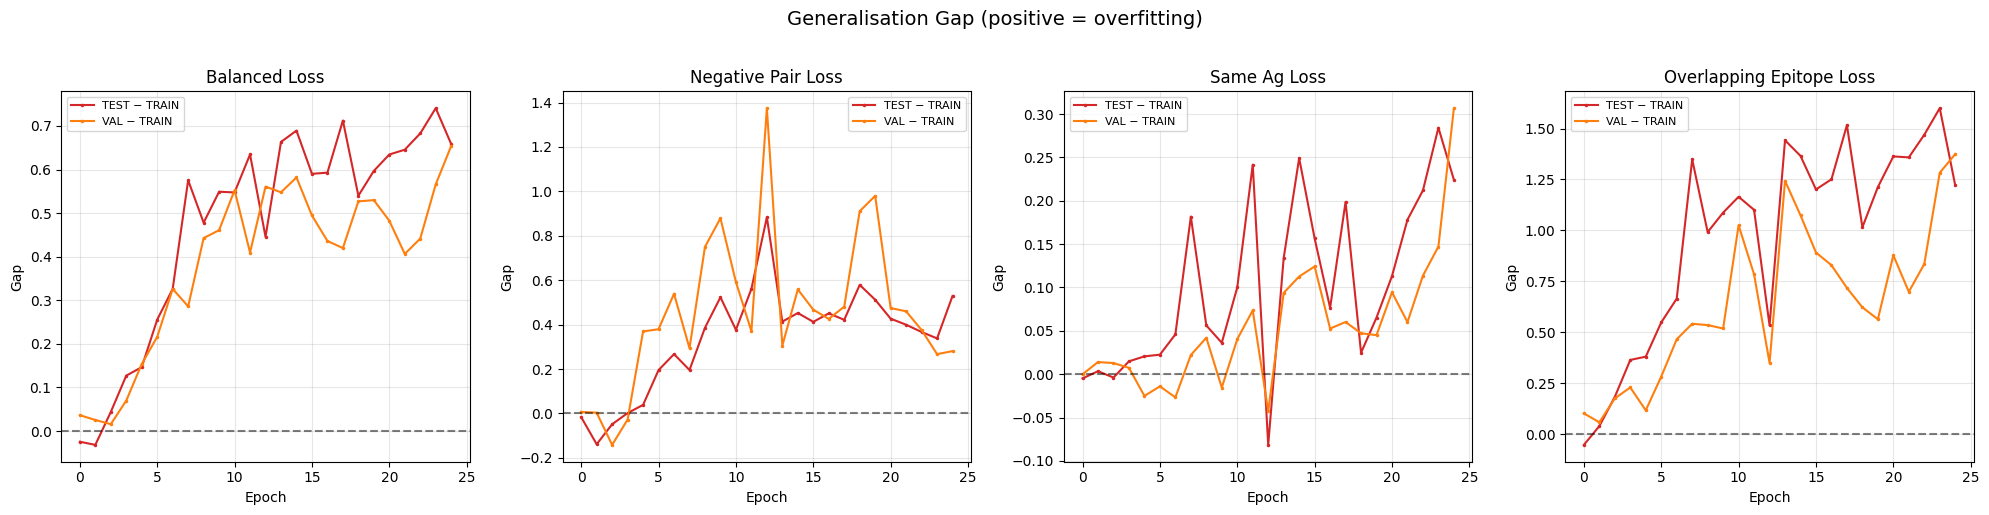

In [6]:
epochs = m["train"]["EPOCH"]
gap_cols = ["BALANCED_LOSS", "NEGATIVE_PAIR_LOSS", "SAME_AG_LOSS", "OVERLAPPING_EPITOPE_LOSS"]

fig, axes = plt.subplots(1, len(gap_cols), figsize=(20, 5))
for col, ax in zip(gap_cols, axes):
    test_gap = m["test"][col] - m["train"][col]
    val_gap = m["val"][col] - m["train"][col]
    ax.plot(epochs, test_gap, label="TEST − TRAIN", color="tab:red", marker=".", ms=3)
    ax.plot(epochs, val_gap, label="VAL − TRAIN", color="tab:orange", marker=".", ms=3)
    ax.axhline(0, color="black", ls="--", alpha=0.5)
    ax.set(xlabel="Epoch", ylabel="Gap", title=col.replace("_", " ").title())
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
plt.suptitle("Generalisation Gap (positive = overfitting)", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

## Nearest-Neighbour Accuracy and F1

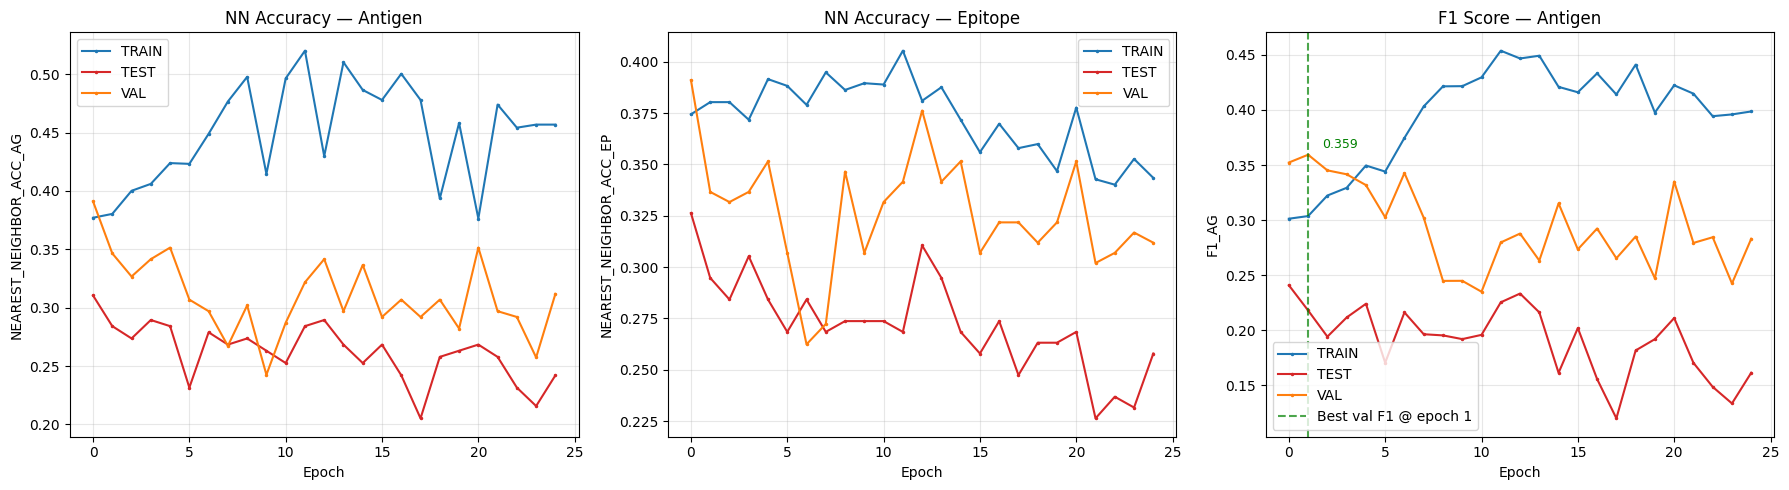

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for col, ax, title in [
    ("NEAREST_NEIGHBOR_ACC_AG", axes[0], "NN Accuracy — Antigen"),
    ("NEAREST_NEIGHBOR_ACC_EP", axes[1], "NN Accuracy — Epitope"),
    ("F1_AG", axes[2], "F1 Score — Antigen"),
]:
    for split, colour in SPLITS.items():
        ax.plot(m[split]["EPOCH"], m[split][col], label=split.upper(), color=colour, marker=".", ms=3)
    ax.set(xlabel="Epoch", ylabel=col, title=title)
    ax.legend()
    ax.grid(True, alpha=0.3)

# Annotate best val F1 epoch
best_val_f1_idx = m["val"]["F1_AG"].arg_max()
best_epoch = m["val"][best_val_f1_idx, "EPOCH"]
best_f1 = m["val"][best_val_f1_idx, "F1_AG"]
axes[2].axvline(best_epoch, color="green", ls="--", alpha=0.7, label=f"Best val F1 @ epoch {best_epoch}")
axes[2].annotate(f"{best_f1:.3f}", (best_epoch, best_f1), textcoords="offset points",
                 xytext=(10, 5), fontsize=9, color="green")
axes[2].legend()

plt.tight_layout()
plt.show()

## Binary Accuracy Metrics

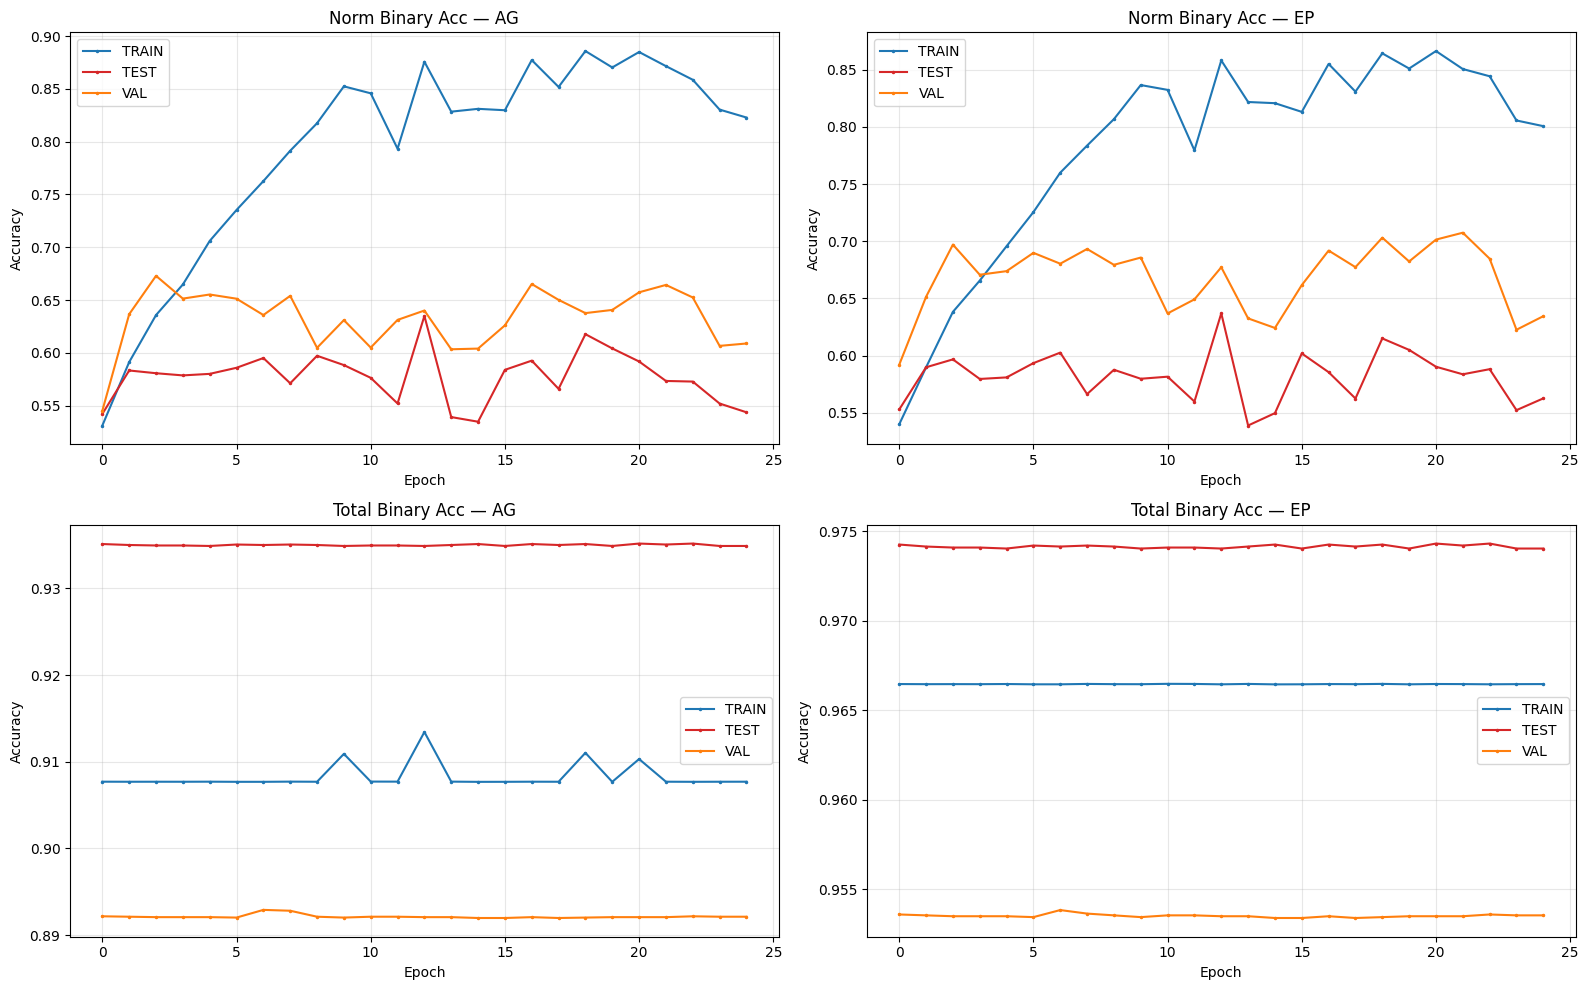

In [12]:
acc_cols = [
    ("NORM_BINARY_ACC_AG", "Norm Binary Acc — AG"),
    ("NORM_BINARY_ACC_EP", "Norm Binary Acc — EP"),
    ("TOT_BINARY_ACC_AG", "Total Binary Acc — AG"),
    ("TOT_BINARY_ACC_EP", "Total Binary Acc — EP"),
]
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
for (col, title), ax in zip(acc_cols, axes.flat):
    for split, colour in SPLITS.items():
        ax.plot(m[split]["EPOCH"], m[split][col], label=split.upper(), color=colour, marker=".", ms=3)
    ax.set(xlabel="Epoch", ylabel="Accuracy", title=title)
    ax.legend()
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Cosine Similarity Thresholds

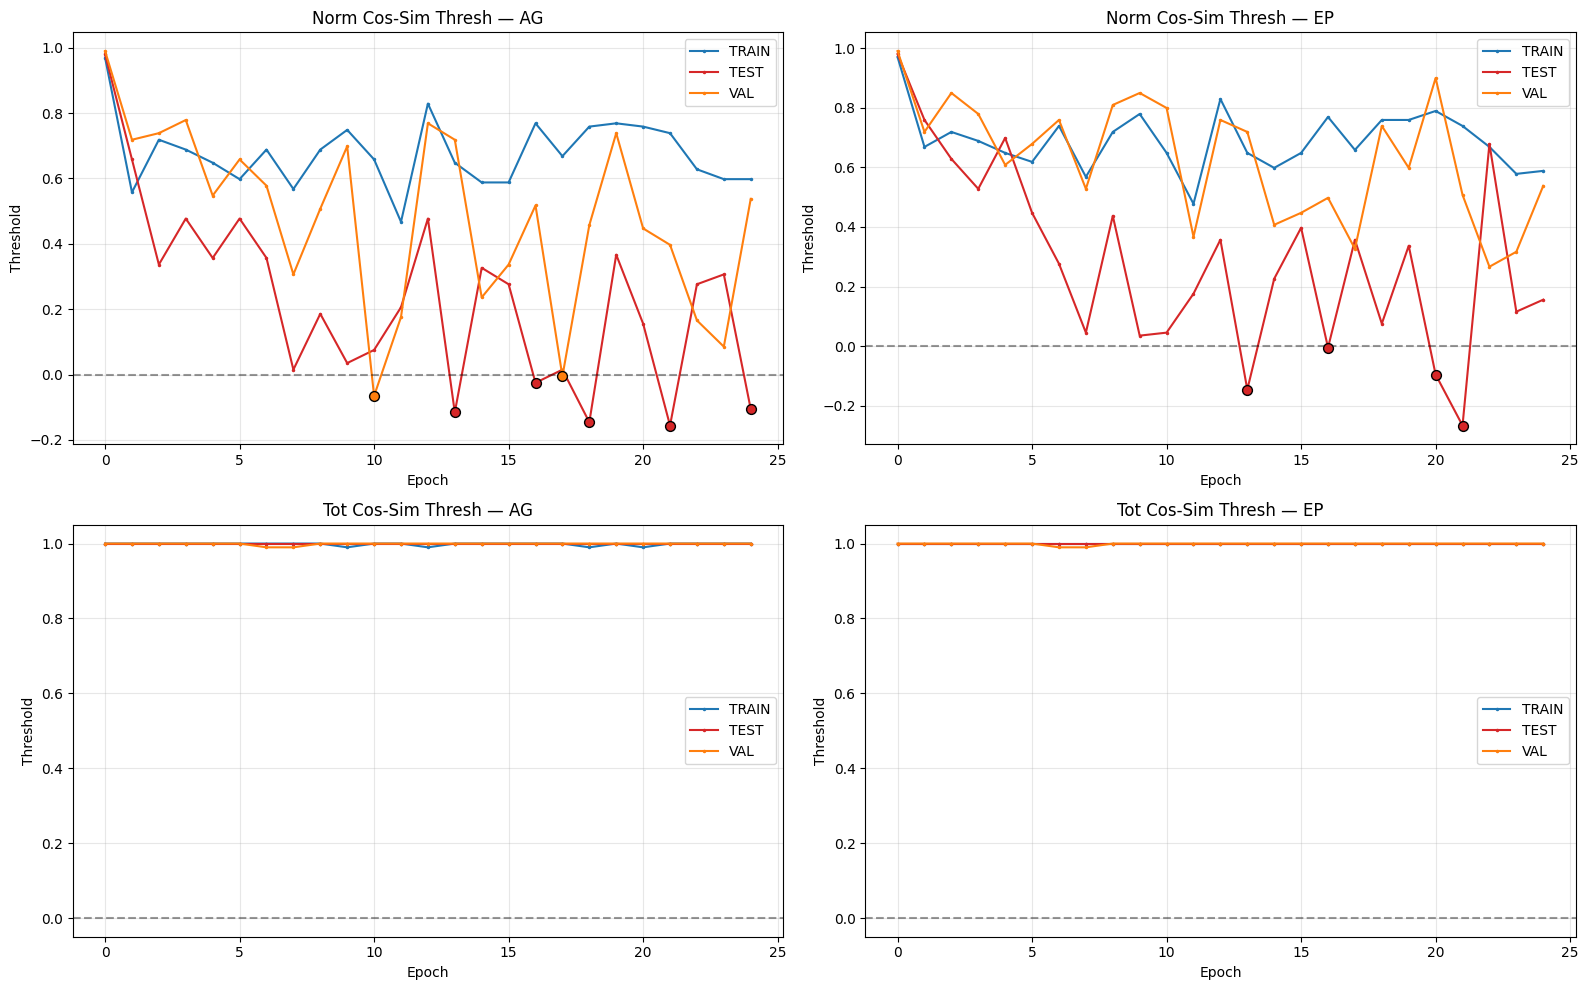

In [14]:
thresh_cols = [
    ("NORM_COS_SIM_THRESH_AG", "Norm Cos-Sim Thresh — AG"),
    ("NORM_COS_SIM_THRESH_EP", "Norm Cos-Sim Thresh — EP"),
    ("TOT_COS_SIM_THRESH_AG", "Tot Cos-Sim Thresh — AG"),
    ("TOT_COS_SIM_THRESH_EP", "Tot Cos-Sim Thresh — EP"),
]
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
for (col, title), ax in zip(thresh_cols, axes.flat):
    for split, colour in SPLITS.items():
        vals = m[split][col]
        ax.plot(m[split]["EPOCH"], vals, label=split.upper(), color=colour, marker=".", ms=3)
        # Highlight negative thresholds
        neg = vals < 0
        if neg.any():
            ax.scatter(m[split]["EPOCH"].filter(neg), vals.filter(neg), color=colour, s=50, zorder=5, edgecolors="black")
    ax.axhline(0, color="black", ls="--", alpha=0.4)
    ax.set(xlabel="Epoch", ylabel="Threshold", title=title)
    ax.legend()
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Ranking Metrics

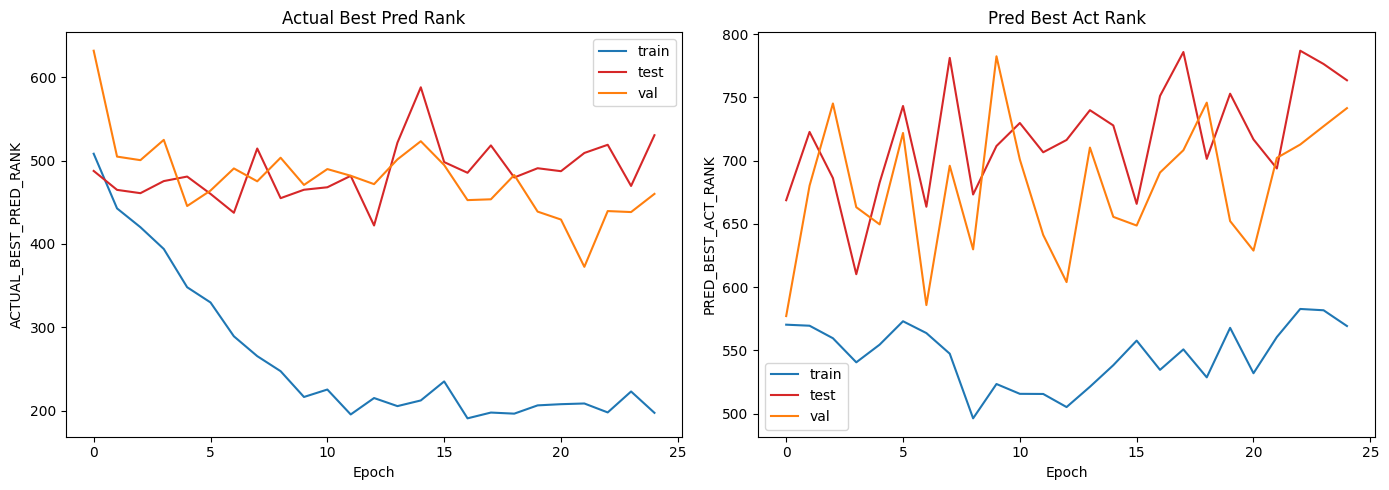

In [17]:
rank_cols = [c for c in m["all"].columns if "RANK" in c.upper()]
if rank_cols:
    fig, axes = plt.subplots(1, len(rank_cols), figsize=(7 * len(rank_cols), 5))
    if len(rank_cols) == 1:
        axes = [axes]
    for ax, col in zip(axes, rank_cols):
        for split, colour in SPLITS.items():
            df = m[split]
            if col in df.columns:
                ax.plot(df["EPOCH"], df[col], label=split, color=colour)
        ax.set_xlabel("Epoch")
        ax.set_ylabel(col)
        ax.set_title(col.replace("_", " ").title())
        ax.legend()
    fig.tight_layout()
    plt.show()
else:
    print("No ranking columns found in metrics.")

## Automated Diagnosis

In [21]:
m = load_metrics()


In [33]:
from IPython.display import Markdown, display

def diagnose(m: dict) -> str:
    """Programmatic overfitting / convergence diagnosis."""
    findings = []
    tr, te, va = m["train"], m["test"], m["val"]
    n = len(tr)
    if n < 3:
        return "**Too few epochs to diagnose.**"

    # --- Loss gap ---
    first_gap = te["BALANCED_LOSS"][0] - tr["BALANCED_LOSS"][0]
    last_gap = te["BALANCED_LOSS"][-1] - tr["BALANCED_LOSS"][-1]
    if last_gap > first_gap * 2:
        findings.append(
            f"🔴 **Generalisation gap widening**: test−train balanced loss went "
            f"from {first_gap:.3f} → {last_gap:.3f}."
        )
    elif last_gap > first_gap * 1.3:
        findings.append(
            f"🟡 **Mild generalisation gap growth**: test−train balanced loss went "
            f"from {first_gap:.3f} → {last_gap:.3f}."
        )

    # --- Test loss trend (last 40% of epochs) ---
    cutoff = max(1, int(n * 0.6))
    te_tail = te["BALANCED_LOSS"][cutoff:]
    slope_test = (te_tail[-1] - te_tail[0]) / max(len(te_tail), 1)
    if slope_test > 0.01:
        findings.append(
            "🔴 **Test loss rising** in the second half of training — "
            "model is overfitting."
        )
    elif abs(slope_test) < 0.005:
        findings.append(
            "🟡 **Test loss plateau** — learning has stalled on held-out data."
        )

    # --- NN accuracy / F1 decline ---
    for metric in ["NN_AG_ACCURACY", "NN_AG_F1"]:
        if metric in te.columns and metric in tr.columns:
            te_best = te[metric].max()
            te_last = te[metric][-1]
            tr_last = tr[metric][-1]
            if te_last < te_best * 0.8:
                findings.append(
                    f"🔴 **{metric}** (test) declined from peak "
                    f"{te_best:.3f} → {te_last:.3f}."
                )
            if tr_last > te_last * 1.5:
                findings.append(
                    f"🟡 **{metric}** train ({tr_last:.3f}) >> test ({te_last:.3f}) "
                    f"— overfitting signal."
                )

    # --- Component-loss divergence ---
    comp_cols = [c for c in tr.columns if c.endswith("_LOSS")]
    for col in comp_cols:
        if col in te.columns:
            tr_drop = tr[col][0] - tr[col][-1]
            te_drop = te[col][0] - te[col][-1]
            if tr_drop > 0 and te_drop < -0.1:
                findings.append(
                    f"🔴 **{col}** diverging: train improving "
                    f"({tr_drop:+.3f}) but test worsening ({te_drop:+.3f})."
                )

    # --- Cosine threshold collapse ---
    thresh_cols = [c for c in te.columns if "THRESH" in c.upper()]
    for col in thresh_cols:
        if te[col][-1] < 0:
            findings.append(
                f"🔴 **{col}** has gone negative ({te[col][-1]:.3f}) — "
                f"embedding space may be collapsing."
            )

    if not findings:
        findings.append("✅ No major issues detected. Training looks healthy.")

    # --- Best epoch ---
    best_col = "NN_AG_F1" if "NN_AG_F1" in va.columns else "BALANCED_LOSS"
    if best_col == "NN_AG_F1":
        best_epoch = va.filter(va[best_col] == va[best_col].max())[0]["EPOCH"]
        best_val = va[best_col].max()
        findings.insert(0, f"📌 **Best val {best_col}**: {best_val:.3f} at epoch {best_epoch}.")
    else:
        best_epoch = va.filter(va[best_col] == va[best_col].min())[0]["EPOCH"]
        best_val = va[best_col].min()
        findings.insert(0, f"📌 **Best val {best_col}**: {best_val:.3f} at epoch {best_epoch}.")

    return "\n\n".join(findings)

report = diagnose(m)
display(Markdown(report))

📌 **Best val BALANCED_LOSS**: 1.996 at epoch shape: (1,)
Series: 'EPOCH' [i64]
[
	7
].

🔴 **Generalisation gap widening**: test−train balanced loss went from -0.024 → 0.658.

🔴 **SAME_AG_LOSS** diverging: train improving (+0.061) but test worsening (-0.168).

🔴 **NORM_COS_SIM_THRESH_AG** has gone negative (-0.106) — embedding space may be collapsing.

In [23]:
m

{'all': shape: (75, 25)
 ┌───────┬─────────┬─────────────┬────────────┬───┬────────────┬────────────┬────────────┬──────────┐
 │ EPOCH ┆ DATASET ┆ UNBALANCED_ ┆ NEGATIVE_P ┆ … ┆ NEAREST_NE ┆ ACTUAL_BES ┆ PRED_BEST_ ┆ F1_AG    │
 │ ---   ┆ ---     ┆ LOSS        ┆ AIR_LOSS   ┆   ┆ IGHBOR_ACC ┆ T_PRED_RAN ┆ ACT_RANK   ┆ ---      │
 │ i64   ┆ str     ┆ ---         ┆ ---        ┆   ┆ _EP        ┆ K          ┆ ---        ┆ f64      │
 │       ┆         ┆ f64         ┆ f64        ┆   ┆ ---        ┆ ---        ┆ f64        ┆          │
 │       ┆         ┆             ┆            ┆   ┆ f64        ┆ f64        ┆            ┆          │
 ╞═══════╪═════════╪═════════════╪════════════╪═══╪════════════╪════════════╪════════════╪══════════╡
 │ 0     ┆ TRAIN   ┆ 8.016353    ┆ 8.80559    ┆ … ┆ 0.374423   ┆ 508.217865 ┆ 570.307922 ┆ 0.301246 │
 │ 0     ┆ TEST    ┆ 8.230843    ┆ 8.789259   ┆ … ┆ 0.326316   ┆ 487.575165 ┆ 668.69281  ┆ 0.240891 │
 │ 0     ┆ VAL     ┆ 7.883752    ┆ 8.812736   ┆ … ┆ 0.3910

## Summary & Recommendations

In [ ]:
summary = """
### Observations

The v1 run shows **clear overfitting** from roughly epoch 5 onwards:

| Signal | Detail |
|--------|--------|
| **Generalisation gap** | Train balanced loss keeps dropping; test/val plateau then rise |
| **NN accuracy & F1** | Train improves; test declines — model memorises training set |
| **Component losses** | `OVERLAPPING_EPITOPE_LOSS` diverges badly (train ↓, test ↑) |
| **Cosine thresholds** | Go negative on test — embedding space is collapsing |

### Root causes (likely)

1. **OneCycleLR too aggressive** — max_lr (5e-4) is 50× the base lr (1e-5), causing
   large parameter updates that overfit quickly.
2. **Insufficient regularisation** — LoRA dropout 0.3 not enough for 1517 training
   antibodies with a 650M-parameter backbone.
3. **No early stopping** — training continues well past the best validation epoch.

### Recommended changes for v2

| Parameter | v1 | v2 |
|-----------|----|----|
| `learning_rate` | 1e-5 | 3e-5 |
| `use_scheduler` | true (OneCycleLR) | true (CosineAnnealingLR) |
| `scheduler_max_lr` | 5e-4 | *(removed — use cosine decay from base lr)* |
| `lora_dropout` | 0.3 | 0.5 |
| `lora_r` | 16 | 8 |
| `lora_alpha` | 32 | 16 |
| `weight_decay` | 0.0 | 0.01 |
| `num_epochs` | 100 | 60 |
| `num_triplets_per_ab_per_epoch` | 3 | 5 |
| `triplet_margin` | 1.0 | 0.5 |
| `patience` (early stopping) | *(none)* | 10 |
"""
display(Markdown(summary))